Analyzing Peng et al. 2019 PDAC dataset — 57,000 cells from 24 tumors and 11 normal pancreas samples. Goal: QC, clustering, and UMAP visualization to identify cell populations in the tumor microenvironment

In [1]:
#import data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import scrublet as scr

/home/akalle1/ls/envs/scrna/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/akalle1/ls/envs/scrna/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/akalle1/ls/envs/scrna/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/akalle1/ls/envs/scrna/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  return module_get_attr_redirect(attr_

In [2]:
#load data
adata = sc.read('Peng2019_raw.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 57530 × 18008
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type'
    var: 'ENSEMBL', 'SYMBOL'


In [3]:
#Explore the metadta
adata.obs['CONDITION']
#how many cells are in each category


T1_AAACCTGAGATGTCGG     T
T1_AAACGGGGTCATGCAT     T
T1_AAAGATGCATGTTGAC     T
T1_AAAGATGGTCGAGTTT     T
T1_AAAGATGGTCTCTCTG     T
                       ..
N11_TTTGCGCGTGCGCTTG    N
N11_TTTGGTTCATTGAGCT    N
N11_TTTGGTTGTCCGACGT    N
N11_TTTGTCAAGGCTAGCA    N
N11_TTTGTCACATCGGACC    N
Name: CONDITION, Length: 57530, dtype: category
Categories (2, str): ['N', 'T']

In [4]:
adata.obs['CONDITION'].value_counts()


CONDITION
T    41986
N    15544
Name: count, dtype: int64

In [5]:
adata.obs['Patient'].value_counts()


Patient
T11    3142
T2     3041
T19    2927
T23    2865
N1     2823
N9     2468
T9     2354
T12    2270
T22    2215
T17    2085
T13    2058
T14    1998
N2     1959
T15    1956
T6     1871
T24    1817
T16    1634
T18    1562
N10    1543
N11    1382
T3     1317
N8     1220
T1     1171
N7     1115
T5     1115
T4     1027
N4      974
N5      887
T10     828
T21     807
T7      747
N6      718
T8      697
T20     482
N3      455
Name: count, dtype: int64

In [6]:
adata.obs['Type'].value_counts()


Type
T    41986
N    15544
Name: count, dtype: int64

In [7]:
adata.obs['Cell_type'].value_counts()

Cell_type
Ductal cell type 2    11315
Ductal cell type 1    10317
Endothelial cell       9117
Fibroblast cell        6742
Stellate cell          5907
Macrophage cell        5361
T cell                 3660
B cell                 2447
Acinar cell            1935
Endocrine cell          729
Name: count, dtype: int64

In [8]:
#Cell types broken by normal and tumor
pd.crosstab(adata.obs['Cell_type'], adata.obs['Type'])

Type,N,T
Cell_type,,
Acinar cell,1423,512
B cell,31,2416
Ductal cell type 1,7671,2646
Ductal cell type 2,0,11315
Endocrine cell,270,459
Endothelial cell,3983,5134
Fibroblast cell,940,5802
Macrophage cell,559,4802
Stellate cell,623,5284


Ductal cell type 2: 0 in normal, 11,315 in tumor. Zero normal. These are the cancer cells — they only exist in tumor samples. This makes perfect sense.
Ductal cell type 1: 7,671 in normal, 2,646 in tumor. Mostly normal tissue. These are the non-malignant ductal cells.
Macrophage: 559 normal, 4,802 tumor. Almost 9x more macrophages in tumor. The tumor is actively recruiting macrophages — these are likely the immunosuppressive M2 TAMs.
Fibroblast: 940 normal, 5,802 tumor. 6x more in tumor. The tumor is activating fibroblasts to build that dense stroma.
Stellate: 623 normal, 5,284 tumor. Same pattern — stellate cells are being activated by the tumor to become CAFs.
T cell: 44 normal, 3,616 tumor. More T cells in tumor, but remember — the tumor samples have way more total cells (41,986 vs 15,544). As a proportion, T cells are still relatively scarce compared to the immunosuppressive cells. And the question for Week 2 is whether those T cells are functional or exhausted.
B cell: 31 normal, 2,416 tumor. Similar pattern.
Acinar: 1,423 normal, 512 tumor. Mostly normal — acinar cells are normal pancreas tissue that gets destroyed as the tumor grows.

Now we start QC. 

In [9]:
print(adata.var.head(10))
print("\n")
# Check if any SYMBOL starts with MT-

mtgenes=adata.var.index[adata.var.index.str.contains('^MT', case=False)]
print(mtgenes.tolist())

                   ENSEMBL     SYMBOL
LINC00115  ENSG00000225880  LINC00115
FAM41C     ENSG00000230368     FAM41C
SAMD11     ENSG00000187634     SAMD11
NOC2L      ENSG00000188976      NOC2L
KLHL17     ENSG00000187961     KLHL17
PLEKHN1    ENSG00000187583    PLEKHN1
HES4       ENSG00000188290       HES4
ISG15      ENSG00000187608      ISG15
AGRN       ENSG00000188157       AGRN
RNF223     ENSG00000237330     RNF223


['MTOR', 'MTHFR', 'MTFR1L', 'MTF1', 'MTF2', 'MTMR11', 'MTX1', 'MTARC2', 'MTARC1', 'MTR', 'MTA3', 'MTIF2', 'MTHFD2', 'MTLN', 'MTX2', 'MTERF4', 'MTMR14', 'MTRNR2L12', 'MTHFD2L', 'MTTP', 'MTRR', 'MTMR12', 'MTREX', 'MTX3', 'MTCH1', 'MTO1', 'MTRES1', 'MTFR2', 'MTHFD1L', 'MTRF1L', 'MTURN', 'MTERF1', 'MTPN', 'MTRNR2L6', 'MTMR8', 'MTM1', 'MTMR1', 'MTMR9', 'MTMR7', 'MTUS1', 'MTFR1', 'MTERF3', 'MTDH', 'MTBP', 'MTSS1', 'MTAP', 'MTPAP', 'MTG1', 'MTRNR2L8', 'MTCH2', 'MTA2', 'MTMR2', 'MTERF2', 'MTMR6', 'MTIF3', 'MTUS2', 'MTRF1', 'MTHFD1', 'MTA1', 'MTMR10', 'MTFMT', 'MTHFS', 'MT3', 'MT2A'

Mitochondrial genes were removed during upstream preprocessing by the Besca pipeline. Mitochondrial-based QC filtering was performed prior to this analysis.

In [10]:
#QC filtering
#check genes are in the SYMBOL column
adata.var.head()
#total counts per cell
adata.var['mt'] = adata.var['SYMBOL'].str.startswith('MT-')
adata.var['mt'] = adata.var['SYMBOL'].str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, inplace=True)
#qc_vars["mt"] =calculte the percentage of counts per gene
#calculated automatically
#n_genes-by_counts=number of genes per cell
#total counts
#pct_counts_mt - mitrochondrial percentage per cell
#mitrochondrial percentage



adata.obs.head()


,CELL,CONDITION,Patient,Type,Cell_type,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
T1_AAACCTGAGATGTCGG,T1_AAACCTGAGATGTCGG,T,T1,T,Fibroblast cell,3343,8.114923,11812.0,9.376956,0.0,0.0,0.0
T1_AAACGGGGTCATGCAT,T1_AAACGGGGTCATGCAT,T,T1,T,Stellate cell,974,6.882437,1935.0,7.568379,0.0,0.0,0.0
T1_AAAGATGCATGTTGAC,T1_AAAGATGCATGTTGAC,T,T1,T,Macrophage cell,1490,7.307202,3811.0,8.245910,0.0,0.0,0.0
T1_AAAGATGGTCGAGTTT,T1_AAAGATGGTCGAGTTT,T,T1,T,Macrophage cell,1101,7.004882,2069.0,7.635304,0.0,0.0,0.0
T1_AAAGATGGTCTCTCTG,T1_AAAGATGGTCTCTCTG,T,T1,T,Endothelial cell,3189,8.067776,8706.0,9.071882,0.0,0.0,0.0


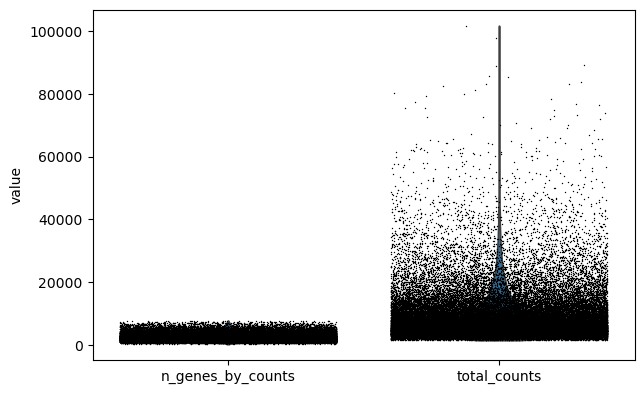

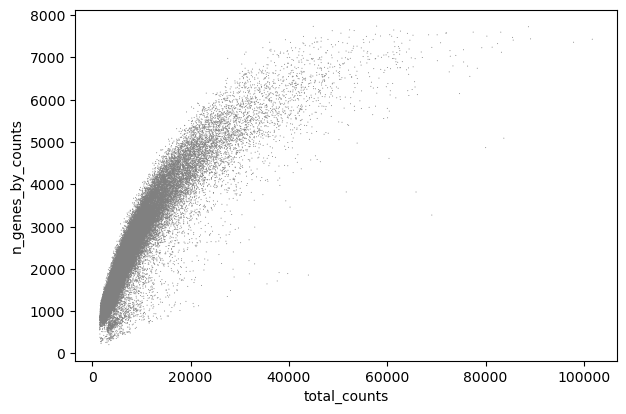

In [11]:
#visualize the QC
#Violin plots- distribution of total counts and genes across all the cells
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts'], jitter =0.4)	
#Scatter plots--total counts vs genes detected 
# Scatter plot - total counts vs genes detected
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')


Violet plot:
The n_genes_by_counts — most cells detect between 500-5,000 genes, with the bulk around 1,000-3,000. No extreme outliers, which suggests some QC was already done upstream.
The total_counts — most cells have between 5,000-30,000 counts, but there's a long tail going up to 100,000. Those very high-count cells at the top could be doublets.
Scatter plot:


In [12]:
print(adata.obs['n_genes_by_counts'].describe())
print("\n")
print(adata.obs['total_counts'].describe())

count    57530.000000
mean      2425.718443
std       1168.364351
min        209.000000
25%       1601.000000
50%       2149.000000
75%       2989.000000
max       7738.000000
Name: n_genes_by_counts, dtype: float64


count     57530.000000
mean       8515.859375
std        7381.626465
min        1485.000000
25%        4119.000000
50%        6123.000000
75%       10037.750000
max      101698.000000
Name: total_counts, dtype: float64


In [13]:
import psutil
print(f"Available RAM: {psutil.virtual_memory().available / 1e9:.1f} GB")
print(f"Total RAM: {psutil.virtual_memory().total / 1e9:.1f} GB")

Available RAM: 5.7 GB
Total RAM: 8.2 GB


I examined the distribution, compared it against standard recommendations from Luecken & Theis, and chose a threshold appropriate for my tissue type and dataset.

In [14]:
import scrublet as scr
import scipy.sparse as sp

# Run Scrublet per sample to save memory
doublet_scores = np.zeros(adata.n_obs)
predicted_doublets = np.zeros(adata.n_obs, dtype=bool)

for sample in adata.obs['Patient'].unique():
    print(f"Processing {sample}...")
    mask = adata.obs['Patient'] == sample
    adata_sample = adata[mask]
    
    X = adata_sample.X
    if not sp.issparse(X):
        X = sp.csr_matrix(X)
    
    scrub = scr.Scrublet(X, expected_doublet_rate=0.06)
    scores, preds = scrub.scrub_doublets(min_counts=2, min_cells=3, n_prin_comps=20)
    
    doublet_scores[mask] = scores
    predicted_doublets[mask] = preds

adata.obs['doublet_score'] = doublet_scores
adata.obs['predicted_doublet'] = predicted_doublets
print(f"\nDetected {predicted_doublets.sum()} doublets out of {len(predicted_doublets)} cells")

Processing T1...
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.40
Detected doublet rate = 0.7%
Estimated detectable doublet fraction = 10.3%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 6.6%
Elapsed time: 1.4 seconds
Processing T2...
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.27
Detected doublet rate = 2.8%
Estimated detectable doublet fraction = 33.2%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 8.5%
Elapsed time: 3.0 seconds
Processing T3...
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.40
Detected doublet rate = 0.5%
Estimated detectable doublet fraction = 19.9%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 2.3%
Elapsed time

When two cells are captured in the same droplet, the resulting "cell" has a transcriptomic profile that is an average of both. In clustering, doublets often appear as a cluster sitting between two real clusters on UMAP, or they contaminate a real cluster with markers from another cell type. Scrublet simulates synthetic doublets by averaging random pairs of cells in your data, then scores each real cell based on how similar it is to the simulated doublets. Cells above a threshold (typically 0.25, but check the bimodal distribution scrublet generates) are flagged and removed.

worked. 655 doublets detected out of 57,530 cells (about 1.1%). That's lower than the expected 6%, which makes sense because the upstream Besca preprocessing likely already removed the most obvious doublets.

In [15]:
#Filter- Remove the doublets
#Before Filtering
print(f"Cells before filtering: {adata.n_obs}")
#Filter
adata = adata[adata.obs['predicted_doublet'] == False].copy()
#After Filtering
print(f"Cells after filtering: {adata.n_obs}")

Cells before filtering: 57530
Cells after filtering: 56875


In [16]:
#Normalization
#Save the raw data
adata.raw = adata.copy()
#normalize
sc.pp.normalize_total(adata, target_sum=1e4)
#log transform- log compresses the range
sc.pp.log1p(adata)

In [17]:
pip install --user scikit-misc

Note: you may need to restart the kernel to use updated packages.


In [18]:
#HVG
#find genes of high variance--> focus--> identify cell identity
#sc.pp.highly_variable_genes()
#picks top 2000 most informative genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3')
print(f"Number of highly variable genes: {adata.var['highly_variable'].sum()}")

/home/akalle1/ls/envs/scrna/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


Number of highly variable genes: 2000


Why: 2,000 dimensions is too many for clustering algorithms to work efficiently. PCA finds the 50 axes that capture the most variation. PC1 might separate immune from epithelial. PC2 might separate T cells from macrophages.

In [19]:
#PCA
sc.pp.pca(adata, n_comps=50)
print(adata.obsm['X_pca'].shape)

(56875, 50)


In [24]:
adata.obsm['X_pca_harmony'] = np.array(harmony_out.Z_corr, dtype=np.float32)
print(f"Harmony corrected shape: {adata.obsm['X_pca_harmony'].shape}")

Harmony corrected shape: (56875, 50)


In [27]:
#build cell neighborhood graph
sc.pp.neighbors(adata, use_rep = "X_pca_harmony")
#UMap
sc.tl.umap(adata)
#calcualtes x, y coordiantes for every cell

In [28]:
#Clustering
#Leiden finds groups of cells that are more connected to each other than to the rest. resolution=0.5 controls how many clusters — higher means more clusters.
sc.tl.leiden(adata, resolution = 0.5)

/tmp/ipykernel_3677/2874732277.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.5)


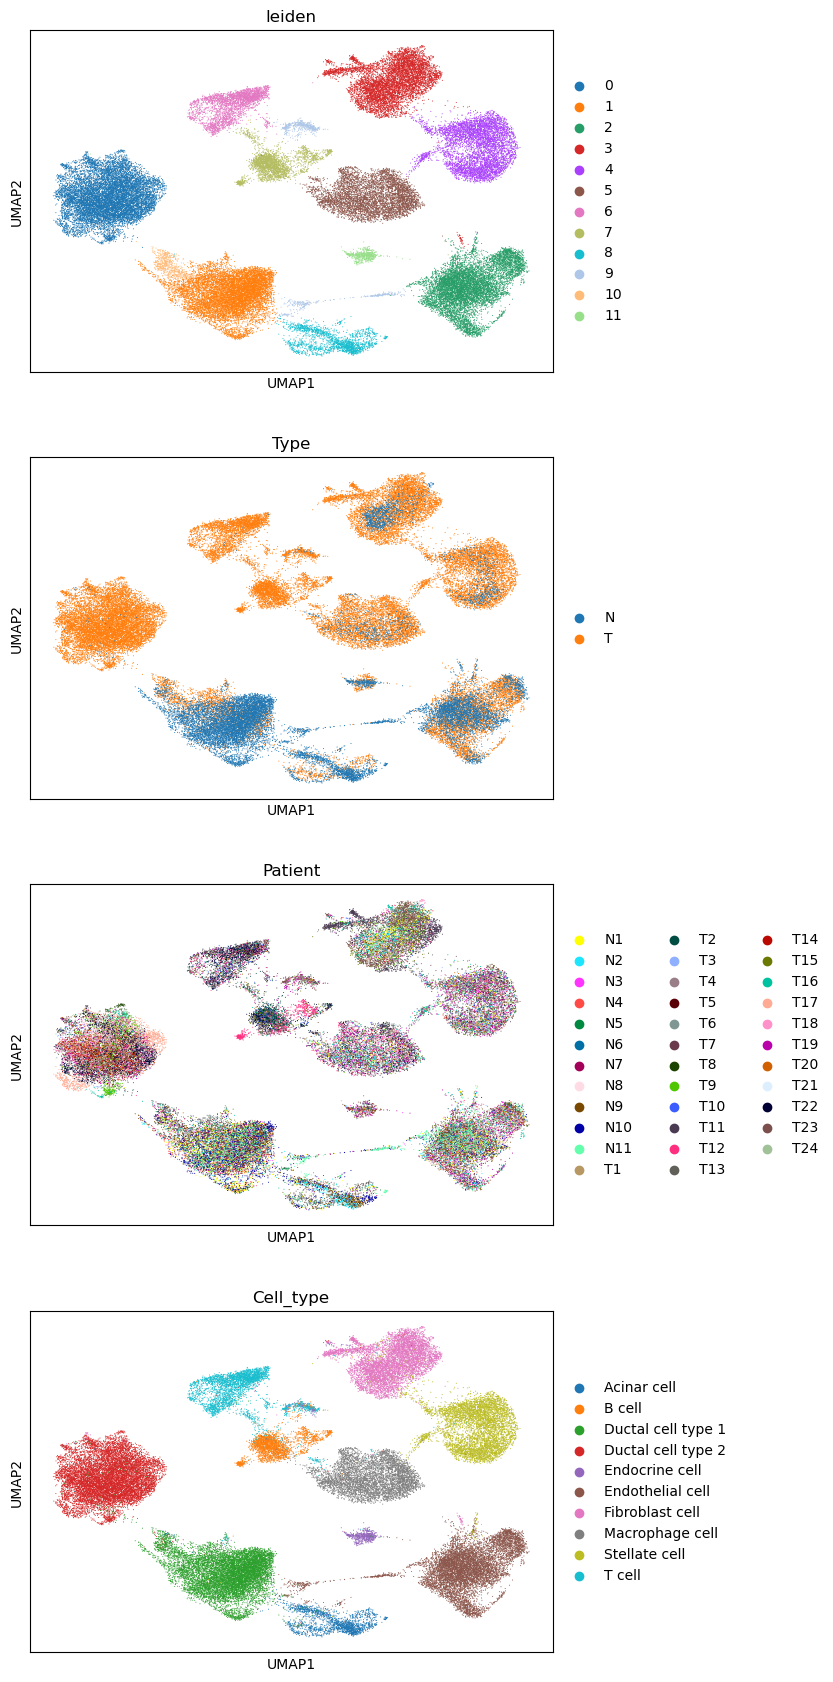

In [31]:
#Plot Umap
sc.pl.umap(adata, color = ['leiden', 'Type', 'Patient', 'Cell_type'], ncols=1)

In [33]:
import anndata
anndata.settings.allow_write_nullable_strings = True
adata.write('Peng2019_processed.h5ad')
print("Saved successfully.")

Saved successfully.
